In [1]:
import jax
import jax.numpy as jnp
import numpy as np
from jax import random
import matplotlib.pyplot as plt
from IPython.display import HTML
import matplotlib.animation as animation
import diffrax as dfx
import diffrax as diffrax
from PIL import Image
import numpy as np
from pde_opt.numerics.domains import Domain
from pde_opt.numerics.shapes import Shape,SpatialHeterogeneity
# from pde_opt.numerics.equations.allen_cahn import AllenCahn2DSmoothedBoundaryButlerVolmerConstantCurrent
from pde_opt.numerics.equations.allen_cahn import AllenCahn2DSBM_BV_CC
from pde_opt.pde_model import PDEModel
from pde_opt.numerics.solvers import ROCK2JAX

In [2]:
def gen_c0(shape, key, noise_fac: float = 0.05, nucsite: jnp.ndarray | None = None) -> jnp.ndarray:
    """
    Generate initial condition array given a Shape.

    Args:
        shape: Shape instance (must have .binary).
        key: JAX PRNGKey
        noise_fac: scale of uniform random perturbation in [-1, 1]
        nucsite: array of nucleation values (same shape as shape.binary),
                 applied only inside the mask. Default: zeros.

    Returns:
        c0: initial concentration array, same shape as shape.binary
    """
    psi_b = shape.binary.astype(jnp.float32)
    H, W = psi_b.shape

    # Uniform noise ∈ [-1, 1], masked by psi_b
    noise = noise_fac * random.uniform(key, (H, W), minval=-1.0, maxval=1.0)

    base = 0.01 * jnp.ones((H, W), dtype=jnp.float32)

    if nucsite is None:
        nucsite = jnp.zeros((H, W), dtype=jnp.float32)
    else:
        nucsite = nucsite.astype(jnp.float32)

    c0 = base + (noise * psi_b) + (psi_b * nucsite)
    return c0

In [3]:
jax.config.update('jax_enable_x64', True)

In [4]:
binary_mask = np.zeros((200, 200))
center = (100, 100)
radius = 75
y, x = np.ogrid[:200, :200]
dist_from_center = np.sqrt((x - center[0]) ** 2 + (y - center[1]) ** 2)
binary_mask[dist_from_center <= radius] = 1

shape = Shape(
    binary=jnp.array(binary_mask),
    dx=(1.0, 1.0),
    smooth_epsilon=3.0,
    smooth_curvature=0.008,
    smooth_dt=0.01,
    smooth_tf=100.0,
)

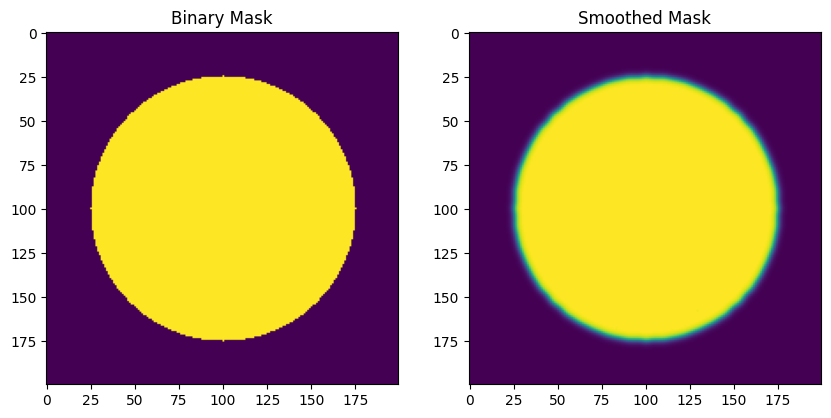

In [5]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(shape.binary)
axs[0].set_title("Binary Mask")
axs[1].imshow(shape.smooth)
axs[1].set_title("Smoothed Mask")
plt.show()

In [6]:
Nx, Ny = binary_mask.shape
pixel_length_rat = 50e-9
Lx=Nx*pixel_length_rat
Ly = Ny*pixel_length_rat
# Lx = 0.01 * Nx
# Ly = 0.01 * Ny

domain = Domain(
    (Nx, Ny), ((-Lx / 2, Lx / 2), (-Ly / 2, Ly / 2)), "dimensionless", shape
)

In [7]:
max(domain.L)

9.999999999999999e-06

In [8]:
kappa = 0.002 #dimensionless
c_max = 2.29e4 #mol/m^3
F = 9.64853321233100184e4 #C⋅mol−1.
k0 = (1e-2 / F) #mol/(m^2 s)
H = 150e-9 #m
C_rate = 1e-2; #1/hr
kappa = 3.1314026858813996e13 #eV/m

In [9]:
kB = 8.617333262145e-5; #Boltzmann Constant [eV/K]
T=298.15; #Temperature [K]
omega = 0.11484582867125136; #eV
omega_tilde = omega / (kB * T)
f=lambda c: c * jnp.log(c) + (1.0 - c) * jnp.log(1.0 - c) + omega_tilde * c * (1.0 - c) + 0.059
mu=lambda c: jnp.log(c / (1.0 - c)) + omega_tilde * (1.0 - 2.0 * c)
j0 = lambda c: jnp.sqrt(c)*(1.0 - c)

In [10]:
# ----------------------------
# 1) Build heterogeneity model
# ----------------------------
Nb = 30
sh = SpatialHeterogeneity.from_shape(
    shape=domain.geometry,      # your Shape
    n_basis=Nb,
    prior_fn=jnp.exp,           # positivity for k(x,y)
)

# Unconstrained eval (not used here, but available)
k_eval_uncon = sh.make_evaluator(apply_mask=False)

# Mean-constrained path
sh.build_mean_constrained(mask_type="binary")   # precompute U etc.
k_eval_mc = sh.make_mean_constrained_evaluator(apply_mask=False)

# Theta init (length matches sh.mean_constrained_U.shape[1])
key = random.PRNGKey(0)
theta0 = random.normal(key, (sh.mean_constrained_U.shape[1],))
# theta0 = jnp.zeros((sh.mean_constrained_U.shape[1],))

In [11]:
# --------------------------------
# 2) Instantiate your PDE (big one)
# --------------------------------
eq = AllenCahn2DSBM_BV_CC(
    domain=domain, kappa=kappa, f=f, mu=mu, j0=j0,
    k0=k0, H=H, Cmax=c_max, Crate=C_rate,
    use_prefactor=True, mean_constrained=True,
    k_eval=None, k_eval_mc=k_eval_mc,
    theta=theta0,
)

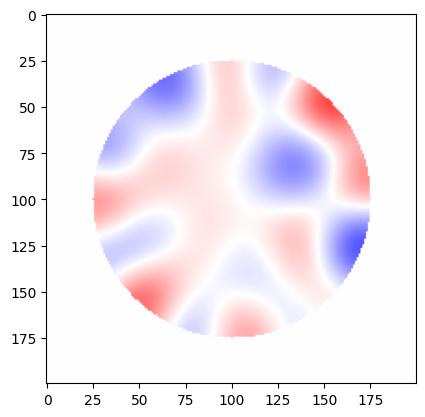

In [12]:
k = eq._k_from_theta()
plt.imshow(k, cmap='bwr',vmin=0.8,vmax=1.2)

In [13]:
# eq = AllenCahn2DSBM_BV_CC(
#     domain,
#     kappa,
#     lambda c: c * jnp.log(c) + (1.0 - c) * jnp.log(1.0 - c) - 3.0 * c * (1.0 - c) + 0.059,
#     lambda c: jnp.log(c / (1.0 - c)) - 3.0 * (1.0 - 2.0 * c),
#     lambda c: jnp.sqrt(c)*(1.0 - c),
#     k0,
#     H,
#     c_max,
#     C_rate,
#     derivs="fd"
# )
# eq = AllenCahn2DSBM_BV_CC(
#     domain,
#     kappa,
#     lambda c: c * jnp.log(c) + (1.0 - c) * jnp.log(1.0 - c) + 4.0 * c * (1.0 - c) + 0.059,
#     lambda c: jnp.log(c / (1.0 - c)) + 4.0 * (1.0 - 2.0 * c),
#     lambda c: jnp.sqrt(c)*(1.0 - c),
#     k0,
#     H,
#     c_max,
#     C_rate,
#     derivs="fd"
# )


In [14]:
# ----------------------------
# 1) Build heterogeneity model
# ----------------------------
Nb = 30
sh = SpatialHeterogeneity.from_shape(
    shape=domain.geometry,      # your Shape
    n_basis=Nb,
    prior_fn=jnp.exp,           # positivity for k(x,y)
)

# Unconstrained eval (not used here, but available)
k_eval_uncon = sh.make_evaluator(apply_mask=False)

# Mean-constrained path
sh.build_mean_constrained(mask_type="binary")   # precompute U etc.
k_eval_mc = sh.make_mean_constrained_evaluator(apply_mask=False)

# Theta init (length matches sh.mean_constrained_U.shape[1])
theta0 = jnp.zeros((sh.mean_constrained_U.shape[1],))

# --------------------------------
# 2) Instantiate your PDE (big one)
# --------------------------------
eq = AllenCahn2DSBM_BV_CC(
    domain=domain, kappa=kappa, f=f, mu=mu, j0=j0,
    k0=k0, H=H, Cmax=c_max, Crate=C_rate,
    use_prefactor=True, mean_constrained=True,
    k_eval=None, k_eval_mc=k_eval_mc,
    theta=theta0,
)



# Build a nucleation map: edges get 0.2, rest 0
psi_edge_inner = shape.get_mask_edge(connectivity=8, side="inner")
nucsite = jnp.where(psi_edge_inner, 0.2, 0.0)

key = random.PRNGKey(0)
u0_edge = gen_c0(shape, key, noise_fac=0.0, nucsite=nucsite)

t_start = 0.0
# tf = eq.Itilde
# tf=1.25*(1/eq.Itilde)
# tf_tilde_est = .9*
t_final = .985*eq.tf_tilde_est
# t_final = .9*eq.tf_tilde_est
# dt = 1e-1
dt= (t_final - t_start)/1000

ts_save = jnp.linspace(t_start, t_final, 200)

def make_soc_event(eqmodel, *, threshold: float = 0.999):
    """
    Build a boolean Event that terminates when SOC exceeds threshold,
    using eqmodel.get_SOC(state).
    """
    def cond_fn(t, y, args, **kwargs):
        soc = eqmodel.get_SOC(y)
        return soc > threshold

    return dfx.Event(cond_fn)
event = make_soc_event(eq, threshold=0.999)

solver = ROCK2JAX()

ode = dfx.ODETerm(lambda t, y, args: eq.rhs(y, t))

solution = dfx.diffeqsolve(
    ode,
    solver,                       # e.g., dfx.Tsit5() or your ROCK2JAX()
    t0=t_start,
    t1=t_final,
    dt0=None,
    y0=u0_edge,
    stepsize_controller=dfx.PIDController(rtol=1e-4, atol=1e-6),
    saveat=dfx.SaveAt(ts=ts_save),
    max_steps=50_000,
    event=event,
)


In [15]:


# Build a nucleation map: edges get 0.2, rest 0
psi_edge_inner = shape.get_mask_edge(connectivity=8, side="inner")
nucsite = jnp.where(psi_edge_inner, 0.2, 0.0)

key = random.PRNGKey(0)
u0_edge = gen_c0(shape, key, noise_fac=0.0, nucsite=nucsite)

In [16]:
key = random.PRNGKey(0)
u0 = jnp.clip(0.05 * jnp.ones((Nx, Ny)) + 0.1 * random.normal(key, (Nx, Ny)), 0.05, 1.0)
# u0 = 0.01 * jnp.ones((Nx, Ny))
print(jnp.max(u0))
print(jnp.min(u0))

0.4498197803499948
0.05


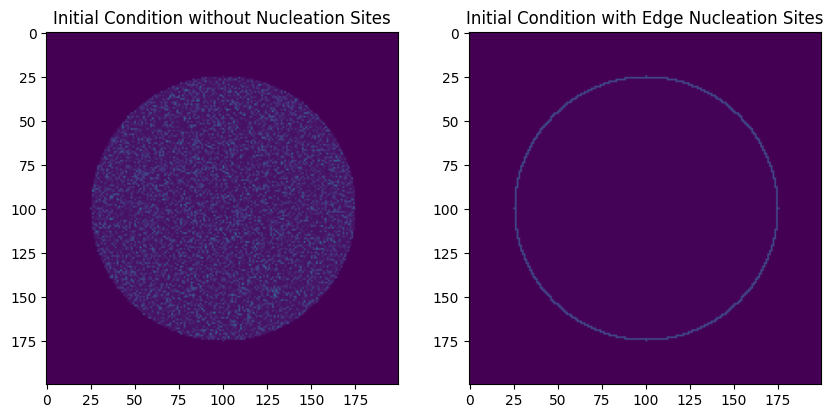

In [17]:
# show edge and normal side by side
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(u0*shape.binary, cmap='viridis', vmin=0, vmax=1)
axs[0].set_title("Initial Condition without Nucleation Sites")
axs[1].imshow(u0_edge*shape.binary, cmap='viridis', vmin=0, vmax=1)
axs[1].set_title("Initial Condition with Edge Nucleation Sites")
plt.show()

In [18]:
t_start = 0.0
# tf = eq.Itilde
# tf=1.25*(1/eq.Itilde)
# tf_tilde_est = .9*
t_final = .985*eq.tf_tilde_est
# t_final = .9*eq.tf_tilde_est
# dt = 1e-1
dt= (t_final - t_start)/1000

ts_save = jnp.linspace(t_start, t_final, 200)


In [19]:
def make_soc_event(eqmodel, *, threshold: float = 0.999):
    """
    Build a boolean Event that terminates when SOC exceeds threshold,
    using eqmodel.get_SOC(state).
    """
    def cond_fn(t, y, args, **kwargs):
        soc = eqmodel.get_SOC(y)
        return soc > threshold

    return dfx.Event(cond_fn)
event = make_soc_event(eq, threshold=0.999)

In [ ]:
3339096# solver_tsit = dfx.Tsit5()
# solver = dfx.Tsit5()
solver = ROCK2JAX()

In [21]:
ode = dfx.ODETerm(lambda t, y, args: eq.rhs(y, t))


In [22]:
solution = dfx.diffeqsolve(
    ode,
    solver,                       # e.g., dfx.Tsit5() or your ROCK2JAX()
    t0=t_start,
    t1=t_final,
    dt0=None,
    y0=u0_edge,
    stepsize_controller=dfx.PIDController(rtol=1e-4, atol=1e-6),
    saveat=dfx.SaveAt(ts=ts_save),
    max_steps=50_000,
    event=event,
)


In [23]:
fig, ax = plt.subplots(figsize=(4, 4))

ims = []
for i in range(0, len(solution.ys), 10):
    img = ax.imshow(
        solution.ys[i]*domain.geometry.binary,
        animated=True, vmin=0.0, vmax=1.0,
        extent=[domain.box[0][0], domain.box[0][1],
                domain.box[1][0], domain.box[1][1]]
    )
    avg = float(jnp.sum(solution.ys[i] * domain.geometry.binary)/jnp.sum(domain.geometry.binary))
    t   = float(solution.ts[i])
    txt = ax.text(
        0.02, 1.02, f"Time: {t:.4f}, Avg Conc: {avg:.4f}",
        transform=ax.transAxes, ha="left", va="bottom", animated=True
    )
    ims.append([img, txt])

ani = animation.ArtistAnimation(fig, ims, interval=200, blit=True, repeat_delay=800)

ax.set_xlabel("x")
ax.set_ylabel("y")
plt.close()
HTML(ani.to_jshtml())


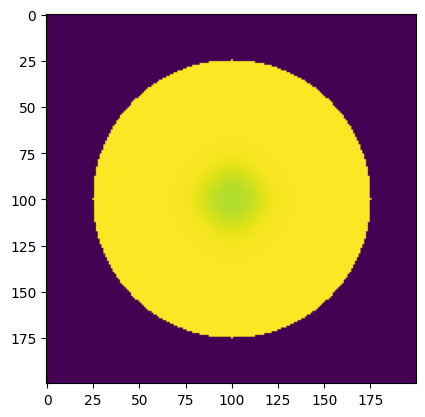

In [24]:
plt.imshow(solution.ys[-2]*domain.geometry.binary, vmin=0, vmax=1)

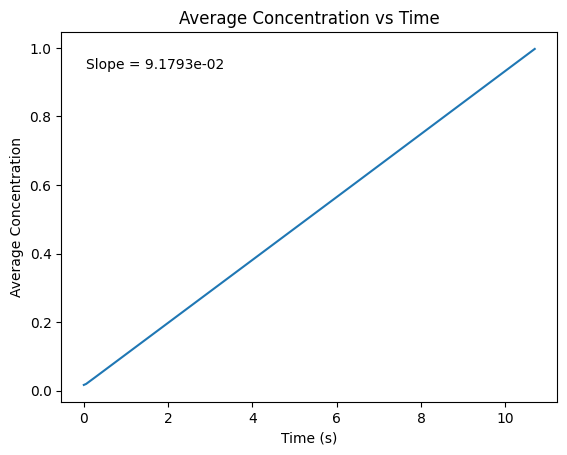

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Extract x and y data
x = np.array(solution.ts)
# y = np.array(jnp.sum(solution.ys * domain.geometry.binary[None], axis=(1,2)))/np.sum(domain.geometry.binary)
# SOC=np.array(jnp.sum(solution.ys * domain.geometry.binary[None], axis=(1,2)))/np.sum(domain.geometry.binary)
SOC = jax.vmap(eq.get_SOC)(solution.ys)
# Fit slope over entire curve
slope, intercept = np.polyfit(solution.ts, SOC, 1)

# Plot
plt.plot(x, SOC)
# plt.ylim(0, 1)
plt.xlabel('Time (s)')
plt.ylabel('Average Concentration')
plt.title('Average Concentration vs Time')
# plt.vlines(x=3600/C_rate, ymin=0, ymax=1, colors='r', linestyles='dashed')

# Add slope text in top-left corner of axes
plt.text(0.05, 0.9, f"Slope = {slope:.4e}", transform=plt.gca().transAxes)

plt.show()


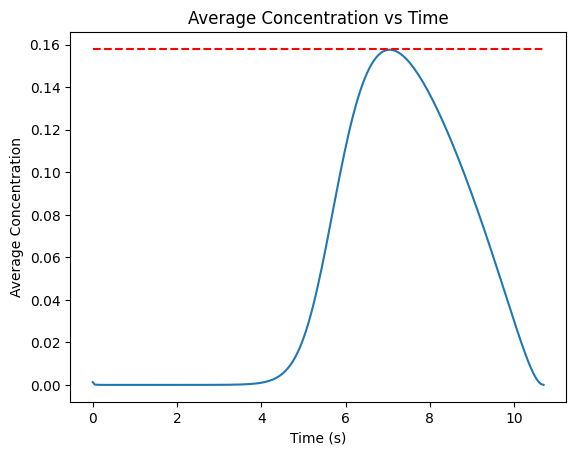

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Extract x and y data
x = np.array(solution.ts)
# y = np.array(jnp.sum(solution.ys * domain.geometry.binary[None], axis=(1,2)))/np.sum(domain.geometry.binary)
# SOC=np.array(jnp.sum(solution.ys * domain.geometry.binary[None], axis=(1,2)))/np.sum(domain.geometry.binary)
cvar = jax.vmap(eq.get_cvar)(solution.ys)
# Fit slope over entire curve
# slope, intercept = np.polyfit(solution.ts, cvar, 1)

# Plot
plt.plot(x, cvar)
# plt.ylim(0, 1)
plt.xlabel('Time (s)')
plt.ylabel('Average Concentration')
plt.title('Average Concentration vs Time')
plt.hlines(y=0.158, xmin=0, xmax=t_final, colors='r', linestyles='dashed')
# plt.vlines(x=3600/C_rate, ymin=0, ymax=1, colors='r', linestyles='dashed')

# Add slope text in top-left corner of axes
# plt.text(0.05, 0.9, f"Slope = {slope:.4e}", transform=plt.gca().transAxes)

plt.show()

In [27]:
eff_crate = 1/((1/slope)*eq.tau_rxn/3600)
# eff_crate = 
print(f"Real C-rate {C_rate}, effective C-rate {eff_crate}")

Real C-rate 0.01, effective C-rate 0.00997070476947692


In [28]:
tf_tilde_est = 1/(C_rate*eq.tau_rxn/3600)
print(f"Estimated tf_tilde {tf_tilde_est}, actual tf_tilde {t_final}")

Estimated tf_tilde 10.862116670318438, actual tf_tilde 10.699184920263662


In [29]:
t_final

10.699184920263662

In [30]:
eff_crate/C_rate

np.float64(0.997070476947692)

In [31]:
eff_crate

np.float64(0.00997070476947692)

In [32]:
eq.Itilde

Array(0.04065736, dtype=float64)

In [33]:
import numpy as np

# Extract x and y data
x = np.array(solution.ts * eq.tau_rxn)
y = np.array(jnp.sum(solution.ys * domain.geometry.binary[None], axis=(1,2)) /
             jnp.sum(domain.geometry.binary[None]))

# Fit a line (degree=1 polynomial)
slope, intercept = np.polyfit(x, y, 1)

# Print slope as txt
with open("slope.txt", "w") as f:
    f.write(f"Slope: {slope:.6f}\nIntercept: {intercept:.6f}\n")

print(f"Slope: {slope:.6f}, Intercept: {intercept:.6f}")


Slope: 0.000003, Intercept: 0.014420


(3.2, 3.5)

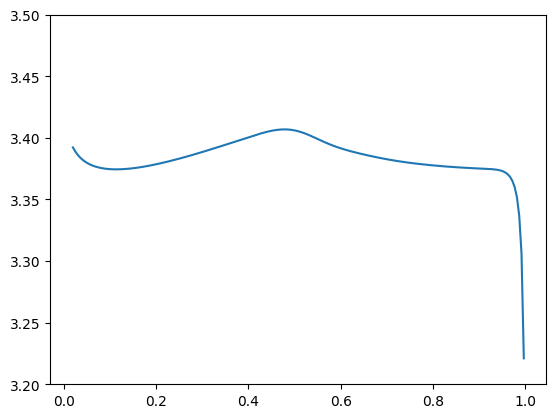

In [34]:
kbt_e=0.0267
voltages =0.0267* jax.vmap(eq.get_voltage)(solution.ys)
plt.plot(SOC[1:],3.42+voltages[1:])
plt.ylim([3.2,3.5])

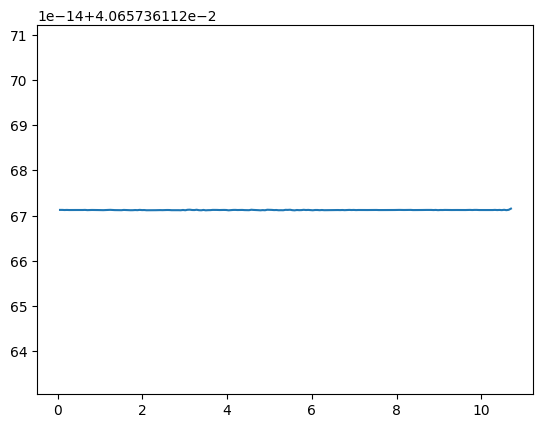

In [35]:
current = jax.vmap(eq.get_current)(solution.ys)
plt.plot(solution.ts[1:],current[1:])